# Investigating multi date experiments

The experimental pipeline that has been set up to evaluate drug responses of MPNST tumors using PDX systems has yielded a large number of tumor response data files, all stored on [Synapse](https://www.synapse.org/Synapse:syn52369030/wiki/623527).
Specifically, we have access to processed data for single agent treatment ([https://www.synapse.org/Synapse:syn65473019](https://www.synapse.org/Synapse:syn65473019)), combination agent treatment ([https://www.synapse.org/Synapse:syn66330226](https://www.synapse.org/Synapse:syn66330226)) as well as a specialized exploration in the combined effects of MEK and EGFR inhibition ([https://www.synapse.org/Synapse:syn71857386](https://www.synapse.org/Synapse:syn71857386)).

For several tumor / single agent treatment evaluations, several experiments were run at different times (not to be confused with timepoints at which tumor viability in response to the agent was measured).
The purpose of this notebook is to look into the impact and potential batch effect of experiments run at different times on the calculated AUCs (and other drug response metrics) via curve fitting.
The specific question this notebooks aims to answer is:

***Can we use the response data from all experiments during the curve fitting procedure?***

Currently, this is how the script generating the curve statistics (`00_createCurveStats.py`) handles the issue with the caveat that the initial set of experiments from Jan 22nd 2025 has been removed from consideration.
The alternative will be to rely only on one set of experiments for example the most recent batch of experiments for each combination of tumor and agent that is tested.

## Setup
Before we start this process we need to define some imports that are necessary.

In [15]:
import synapseclient as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
# import subprocess

## Basic exploration of the experimental data

To get a better feel for how experimental setups from different dates for a given tested combination of tumor & agent are behaving we will do some basic exploration of the data. To start of we specifically look at the example of JH-2-002 treated with TNO155.

### File import

First we define the synapse ids, for the files that we are specifically interested in and import those into data frames for further investigation.

All of the experiments that are imported are:

- JH-2-002
- TNO155 treated
- Day2 Growth

Data is available for experiments from four different dates with the associated synapse ids (`synapse_ids`).
We will temporarily store all downloaded DataFrames into a dictionary (`dfs`).

In [16]:
synapse_ids = {
    '2025-01-22': 'syn65660962',
    '2025-04-01': 'syn66724858',
    '2025-04-08': 'syn66724871',
    '2025-05-13': 'syn66694987',
}

dfs = {}

Using the `synapseclient` API we login to Synapse, retrieve the four files defined using their synapse id (`syn_id`), and also addionally store the date information into the associated DataFrame into a `date` column.

In [17]:
syn = sc.login()
for date, syn_id in synapse_ids.items():
    dfs[date] = pd.read_csv(syn.get(syn_id).path)
    dfs[date]['date'] = date

syn.logout()

Welcome, ymahlich! You are using the 'default' profile.
[syn65660962:JH2002_TNO155_Day2_250122.csv]: Found existing file at /Users/mahl006/.synapseCache/439/154268439/JH2002_TNO155_Day2_250122.csv, skipping download.
[syn66724858:JH2002_TNO155_Day2_250401.csv]: Found existing file at /Users/mahl006/.synapseCache/514/156823514/JH2002_TNO155_Day2_250401.csv, skipping download.
[syn66724871:JH2002_TNO155_Day2_250408.csv]: Found existing file at /Users/mahl006/.synapseCache/540/156823540/JH2002_TNO155_Day2_250408.csv, skipping download.
[syn66694987:JH2002_TNO155_Day2_250513.csv]: Found existing file at /Users/mahl006/.synapseCache/211/156673211/JH2002_TNO155_Day2_250513.csv, skipping download.


Finally we concatenate all of the four DataFrames into one final DataFrame (`df`) that we use for the basic evaluation.

In [18]:
df = pd.concat(dfs.values())

### Investigating deviations of viability scores

Note that each date contains 3 replicates (different `specimenID`) per concentration.

Below is an example for:
- viability measure (`percentViability`)
- of replicates 1-3 (`specimenID`)
- treated with 300µM (`concentration`) of TNO155 (`drugName`)
- for experiments from (`date`)
  - 2025/01/22
  - 2025/04/01

In [19]:
df.loc[df['concentration'] == 300, ['date', 'specimenID', 'drugName', 'concentration', 'percentViability']].head(6)

,date,specimenID,drugName,concentration,percentViability
0,2025-01-22,JH2002 rep1,TNO155,300.0,16.829710
8,2025-01-22,JH2002 rep2,TNO155,300.0,17.762540
16,2025-01-22,JH2002 rep3,TNO155,300.0,14.870420
0,2025-04-01,JH2002 rep1,TNO155,300.0,6.728827
8,2025-04-01,JH2002 rep2,TNO155,300.0,5.311851
16,2025-04-01,JH2002 rep3,TNO155,300.0,8.218168


As can be seen in the `percentViability` column of the output displayed above, the delta between viability measures of replicates within a date is less than between replicates across different experiment dates.
To visualize this behaviour we will plot all viability percentages across all dates and replicates. 

#### Plotting viability scores across dates and 
The code block below plots viability scores for each concentration, grouped by date, i.e. 3 measures per date and concentration combination, one per replicate.
The x-Axis (concentration) is in logarithmic scale to better visualize the viability deviations at each individual concentration.

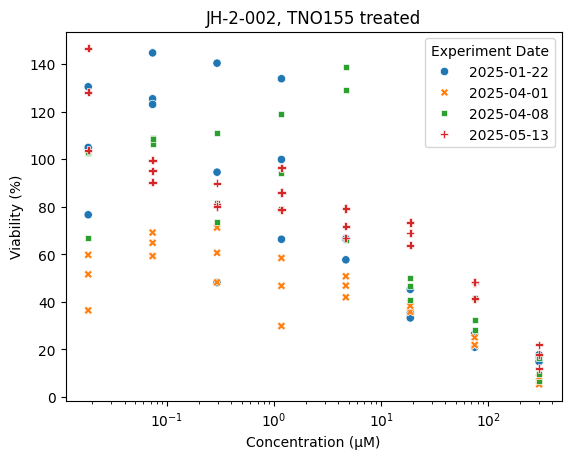

In [20]:
plot_all = sns.scatterplot(
    data=df,
    x='concentration',
    y='percentViability',
    hue='date',
    style='date',
    )

plt.xscale("log")
plt.title("JH-2-002, TNO155 treated")
plt.ylabel("Viability (%)")
plt.xlabel("Concentration (µM)")
plot_all.legend(title='Experiment Date')

As expected viability is more variable with smaller concentrations and converges with higher concentrations.
We can also see that variance within a given date (across the different replicates) is generally lower.

#### Mean viability percentages per concentration grouped by date (i.e. the mean across replicates)

To further illustrate the fact that there is a large discrepancy in reported viability for the same drug concentration across different experiment dates, we will plot the mean percentViability per concentration and date.

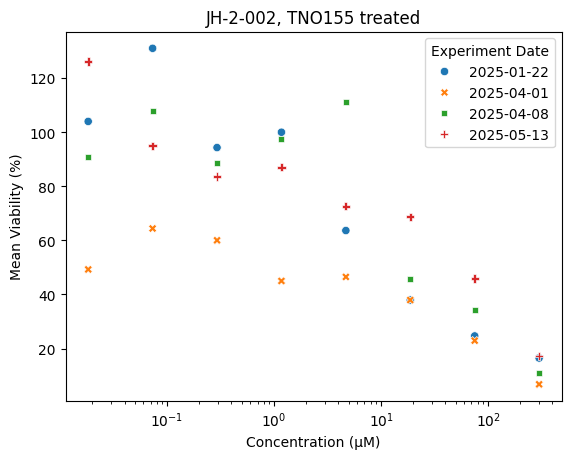

In [21]:
df_mean = (df
    .groupby(['concentration', 'date'], as_index=False)['percentViability']
    .mean()
)

plot_mean = sns.scatterplot(
    data=df_mean,
    x='concentration',
    y='percentViability',
    hue='date',
    style='date'
    )
plt.xscale("log")
plt.title("JH-2-002, TNO155 treated")
plt.ylabel("Mean Viability (%)")
plt.xlabel("Concentration (µM)")
plot_mean.legend(title='Experiment Date')

#### Standard deviation of viability percentages per concentration grouped by date (i.e. the mean across replicates)

Finally, to visualize the discrepancies of viability within a given concentration & date combination (i.e. between replicates) we plot the standard deviation of the `percentViability`.
Admittedly, given that the deviation is calculated based on only 3 values per reported standard deviation (same as with the mean viability), the power of the anlysis is limited.
Yet, it still illustrates the fact that there is a lot of variability within the data.

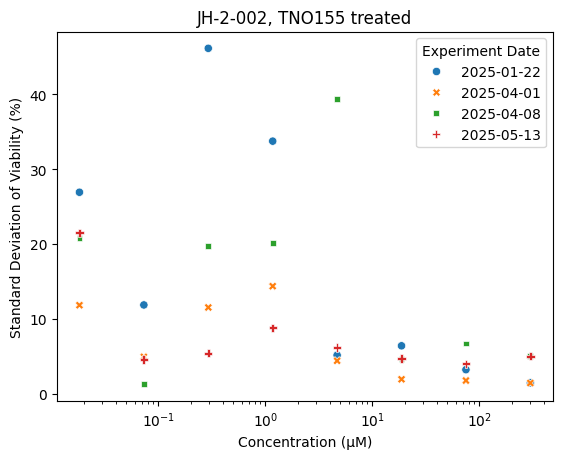

In [22]:
df_std = (df
    .groupby(['concentration', 'date'], as_index=False)['percentViability']
    .std()
)

plot_std = sns.scatterplot(
    data=df_std,
    x='concentration',
    y='percentViability',
    hue='date',
    style='date',
    )

plt.xscale("log")
plt.title("JH-2-002, TNO155 treated")
plt.ylabel("Standard Deviation of Viability (%)")
plt.xlabel("Concentration (µM)")
plot_std.legend(title='Experiment Date')

All 3 plots demonstrate that there is considerable variability of reported viability (per concentration) both across as well as within experiment dates.

#### Comparision of AUC & R^2 based on individual date data vs data from all dates

As a final evaluation specifically for the example of JH-2-002 treated with TNO155 (at the 48h mark) we will be performing the curve fitting based on individual experiment dates to retrieve drug response metrics like AUC and compare that against the drug response metrics obtained by running the curve fitting based on the combined data from all 4 dates.

To that end we first define some helper functions to preprocess the data, respectively initialize the curve fitting.

##### Helper function to fit curves

Note that this function is loosely based on functionality available in `00_createCurveStats.py` and only copied here for quicker access and additional clean up of the function.

In [23]:
from copy import deepcopy
import os
import subprocess

def fit_curves(df: pd.DataFrame, group_by_date: bool=False):

    fulltab = deepcopy(df)

    """
    The renaming of columns has to be done such that the column names
    are compatible with the prexisting curve fitting script lifted from
    coderdata.
    """
    fulltab = fulltab.rename(
        columns={
            "concentration": "DOSE",
            "percentViability": "GROWTH",
            "timePoint": "time",
            "timePointUnit": "time_unit",
            "drugName": "Drug"}
        )
    
    """
    Adding in additional columns that the curve fitting script expects
    """
    fulltab['study']='mpnstPDXMT'
    fulltab['source']='synapse'
    if group_by_date:
        fulltab['improve_sample_id'] = (
            fulltab['sampleName'].astype(str)
            + '_'
            + fulltab['date'].astype(str)
        )
    else:
        fulltab['improve_sample_id'] = fulltab['sampleName']
    
    """
    Rearranging the columns to be in the order expected by the curve
    fitting script
    """
    ncols = [
        'DOSE',
        'GROWTH',
        'study',
        'source',
        'improve_sample_id',
        'Drug',
        'time',
        'time_unit'
        ]
    fulltab = fulltab[ncols]
    
    """
    changing the values in the `GROWTH` column to numeric (i.e. making
    sure that there aren't any artefacts) and saving the DataFrame to a
    temporary file that the curve fitting script can import.
    """
    fulltab['GROWTH'] = pd.to_numeric(fulltab['GROWTH'])
    fulltab.to_csv('mpnst_drug_response.tsv', sep='\t')
    
    """
    Routine to run the curve fitting script. If the script is not
    available locally we will retrieve it from the coderdata git
    repository.
    Once available locally we will execute the script with the
    previously generated csv as input.
    """
    script = (
        'https://raw.githubusercontent.com/PNNL-CompBio/coderdata/'
        'refs/heads/main/coderbuild/utils/fit_curve.py'
    )
    if not os.path.exists("fit_curve.py"):
        subprocess.run(['wget', script, '-O', 'fit_curve.py'])
    
    """
    Executing the actual curve fitting
    """
    subprocess.run([
        'python', 'fit_curve.py',
        '--input', 'mpnst_drug_response.tsv',
        '--output', 'mpnstDrugOutput'
    ])

    """
    Importing the result file generated by the curve fitting script into
    a DataFrame and returning it.
    """
    otab = pd.read_csv('mpnstDrugOutput.0', sep='\t')
    return otab


#### Generation of drug response metrics

As mentioned previously the drug respones metrics (e.g. AUC & R^2) are generated using the curve fitting algorithm also employed in coderdata.
The next code block uses the helper function defined above to generate input files where individual combinations of tumor sample and tested agent are grouped by date i.e., the experiments measuring tumor viability of JH-2-002 treated with TNO155 from 2025/01/22 & 2025/04/01 are regarded as separate experiments and curve fitting is done individually for each of these.

As second prepatory step for plotting the results the `improve_sample_id` that is generated by the `fit_curves()` function which contains the date of the experiment is separated into two distinct columns recording the original `improve_sample_id` as well as the `date`.

In [24]:
df_grp_by_date_curve_fit_results = fit_curves(df, group_by_date=True)
df_grp_by_date_curve_fit_results[['improve_sample_id', 'date']] = (
    df_grp_by_date_curve_fit_results['improve_sample_id']
    .str.split('_', expand=True)
)

mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-0nwsi96n because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


mpnst_drug_response.tsv
<bound method NDFrame.head of     Unnamed: 0      DOSE    GROWTH  ...    Drug time time_unit
0            0  3.522879  0.168297  ...  TNO155   48     hours
1            1  4.124939  0.209116  ...  TNO155   48     hours
2            2  4.726999  0.452529  ...  TNO155   48     hours
3            3  5.329059  0.667816  ...  TNO155   48     hours
4            4  5.931119  0.998713  ...  TNO155   48     hours
..         ...       ...       ...  ...     ...  ...       ...
91          19  5.329059  0.668870  ...  TNO155   48     hours
92          20  5.931119  0.859856  ...  TNO155   48     hours
93          21  6.533179  0.898658  ...  TNO155   48     hours
94          22  7.135239  0.903443  ...  TNO155   48     hours
95          23  7.737299  1.466092  ...  TNO155   48     hours

[96 rows x 9 columns]>
we have 12 cores and 11 threads


mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-bntf0q9o because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended t

Analogous to the previous codeblock, we generate drug response metrics, however this time we do not group by date.
Instead all viability measures for a given combination of tumor sample and drug are combined into one and drug response is calculated based on the combined data.

Finally, we indicate this fact by setting the `data` to `combined`.

In [25]:
df_all_dates_curve_fit_results = fit_curves(df, False)
df_all_dates_curve_fit_results['date'] = 'combined'

mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-smhvrk_c because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


mpnst_drug_response.tsv
<bound method NDFrame.head of     Unnamed: 0      DOSE    GROWTH  ...    Drug time time_unit
0            0  3.522879  0.168297  ...  TNO155   48     hours
1            1  4.124939  0.209116  ...  TNO155   48     hours
2            2  4.726999  0.452529  ...  TNO155   48     hours
3            3  5.329059  0.667816  ...  TNO155   48     hours
4            4  5.931119  0.998713  ...  TNO155   48     hours
..         ...       ...       ...  ...     ...  ...       ...
91          19  5.329059  0.668870  ...  TNO155   48     hours
92          20  5.931119  0.859856  ...  TNO155   48     hours
93          21  6.533179  0.898658  ...  TNO155   48     hours
94          22  7.135239  0.903443  ...  TNO155   48     hours
95          23  7.737299  1.466092  ...  TNO155   48     hours

[96 rows x 9 columns]>
we have 12 cores and 11 threads


mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-5yxynbi0 because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended t

In the final step before plotting the results we combine the two generated sets of drug respones metrics.
Furthermore, we generate a view on the DataFrame that contains only `auc`, `fit_auc` & `fit_r2` values which will be used as input for the plotting function.

In [26]:
df_response = pd.concat(
    (df_grp_by_date_curve_fit_results, df_all_dates_curve_fit_results)
)

metrics = ['auc', 'fit_auc', 'fit_r2']
df_response_to_plot = df_response[
    df_response["dose_response_metric"].isin(metrics)
]

df_response_to_plot.head()

,source,improve_sample_id,improve_drug_id,study,time,time_unit,dose_response_metric,dose_response_value,date
0,synapse,JH-2-002,TNO155,mpnstPDXMT,48,hours,fit_auc,0.8177,2025-01-22
1,synapse,JH-2-002,TNO155,mpnstPDXMT,48,hours,fit_auc,0.5644,2025-04-01
2,synapse,JH-2-002,TNO155,mpnstPDXMT,48,hours,fit_auc,0.8699,2025-04-08
3,synapse,JH-2-002,TNO155,mpnstPDXMT,48,hours,fit_auc,0.8697,2025-05-13
12,synapse,JH-2-002,TNO155,mpnstPDXMT,48,hours,fit_r2,0.8564,2025-01-22


#### Plotting the curve fitting results

Below we plot the results comparing generated the values for drug response metrics grouped by individual dates vs. a combined datasets where curve fitting was performed based on all data points.

For this example of JH-2-002 treated with TNO155 at 48h we can make several observations:

1. 2025-04-01 reperesents an outlier where calculated AUC and fitted AUC values differ significantly from the other 3 dates. Importantly the calculated R^2 value that indicates the "quality" of the curve fit is also significalty lower.
2. AUC & fitted AUC values calculated for the combined dataset dose not seem to significantly impacted by the 2025-04-01 outlier. However the calculate R^2 value for the curve fit is significantly worse at ~0.65 in comparison to >0.8 for 01-22, 04-08 & 05-13 and much closer to that of the 04-01 outlier.

This leads back to the initial question: Which datasets should we base the calculation of the drug response metrics on and does it make sense to combine all datasets into one.

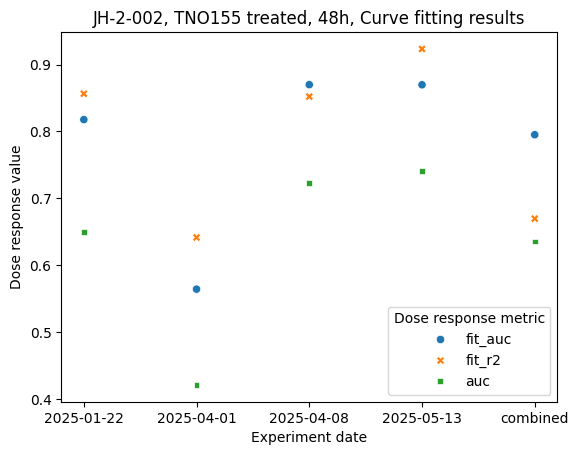

In [27]:
plot_auc = sns.scatterplot(
    data=df_response_to_plot,
    x='date',
    y='dose_response_value',
    hue="dose_response_metric",
    style='dose_response_metric'
)

plt.title("JH-2-002, TNO155 treated, 48h, Curve fitting results")
plt.ylabel("Dose response value")
plt.xlabel("Experiment date")
plot_auc.legend(title='Dose response metric')

## Investigating trends across all drug screens